In [ ]:
!pip install ptitprince

In [ ]:
!pip install  matplotlib==3.7.4

In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
#sns.set(style="darkgrid")
#sns.set(style="whitegrid")
#sns.set_style("white")
sns.set(style="whitegrid",font_scale=2)
import matplotlib.collections as clt
import ptitprince as pt

In [49]:
#图片保存及输出设置
savefigs = True
figs_dir = 'figs'
if savefigs:
    # Make the figures folder if it doesn't yet exist
    #如果没有找到文件夹，先创建此文件夹
    if not os.path.isdir(figs_dir):
        os.makedirs(figs_dir)

def export_fig(axis,text, fname):
    if savefigs:
        axis.text()
        axis.savefig(fname, bbox_inches='tight')     


In [51]:
df = pd.read_csv ("simdat.csv", sep= ",")
df.head()

,Unnamed: 0,group,score,gr2
0,1,Group1,34.318801,high
1,2,Group1,40.113776,high
2,3,Group1,93.387266,high
3,4,Group1,46.235969,high
4,5,Group1,47.537756,high


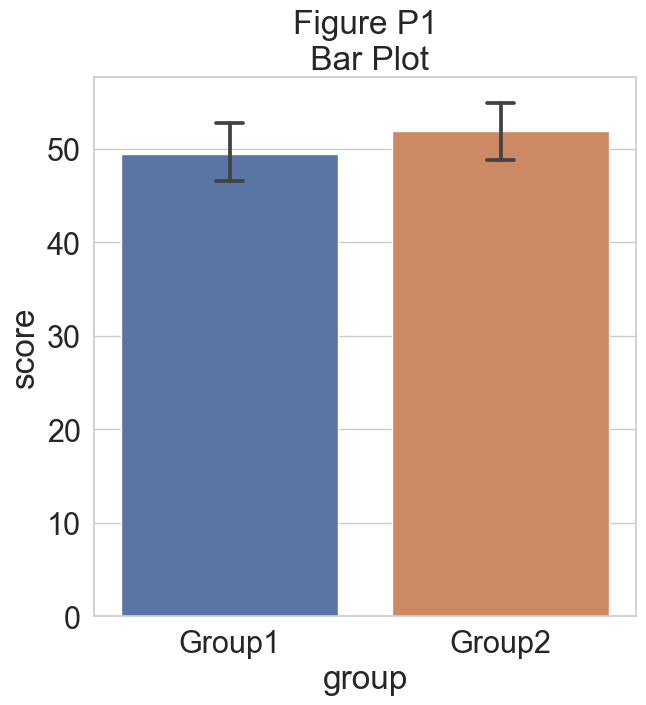

In [53]:
f, ax = plt.subplots(figsize=(7, 7))
sns.barplot(x = "group", y = "score", data = df, capsize= .1)
plt.title("Figure P1\n Bar Plot")
if savefigs:
    plt.savefig('figs/figureP01.png', bbox_inches='tight')

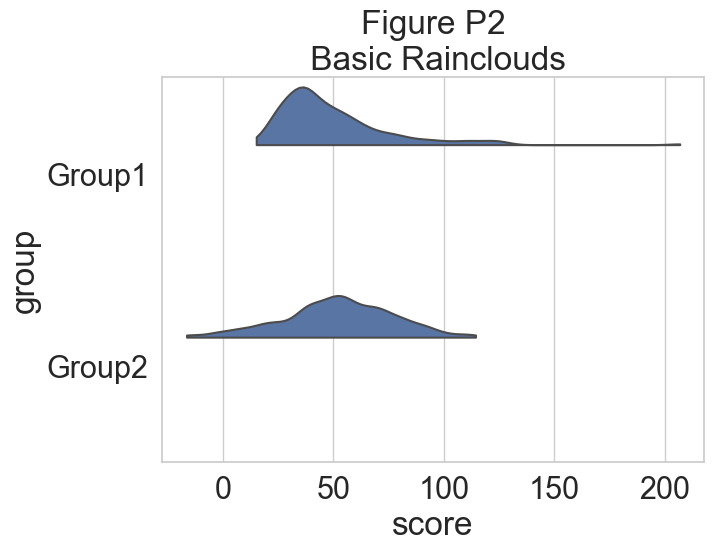

In [19]:
# plotting the clouds
f, ax = plt.subplots(figsize=(7, 5))
dy="group" 
dx="score"
ort="h"
pal = sns.color_palette(n_colors=1)
ax=pt.half_violinplot(x=dx, y=dy, data=df, palette=pal, bw=.2, cut=0., scale="area", width=.6, inner=None, orient=ort)
plt.title("Figure P2\n Basic Rainclouds")
if savefigs:
    plt.savefig('figs/figureP02.png', bbox_inches='tight')


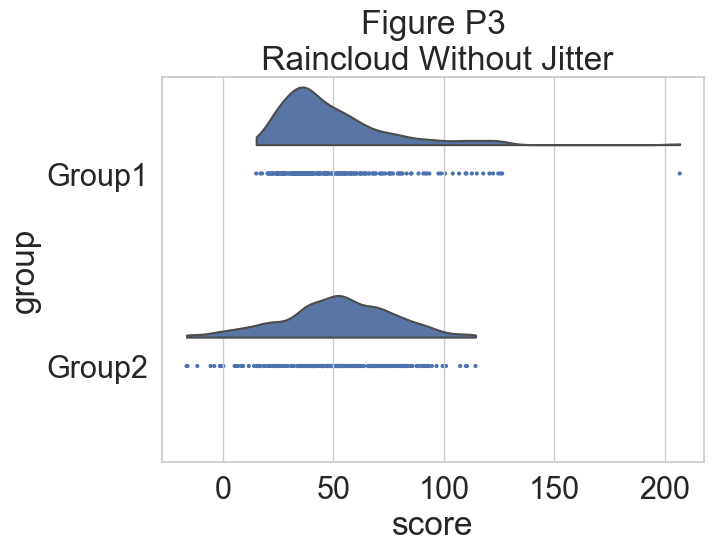

In [21]:
# adding the rain
f, ax=plt.subplots(figsize=(7, 5))
ax=pt.half_violinplot(x=dx, y=dy, data=df, palette=pal, bw=.2, cut=0., scale="area", width=.6, inner=None, orient=ort)
ax=sns.stripplot(x=dx, y=dy, data=df, palette=pal, edgecolor="white", size=3, jitter=0, zorder=0, orient=ort)
plt.title("Figure P3\n Raincloud Without Jitter")
if savefigs:
    plt.savefig('figs/figureP03.png', bbox_inches='tight')


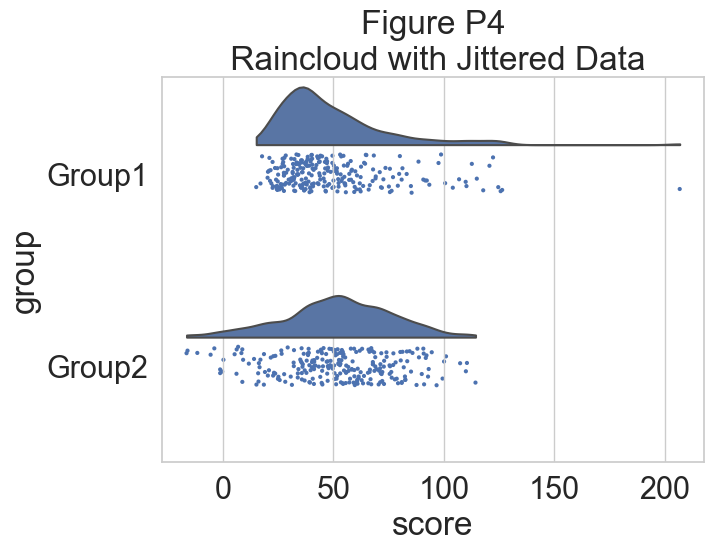

In [23]:
# adding jitter to the rain
f, ax =plt.subplots(figsize=(7, 5))
ax=pt.half_violinplot(x=dx, y=dy, data=df, palette=pal, bw=.2, cut=0., scale="area", width=.6, inner=None, orient=ort)
ax=sns.stripplot(x=dx, y=dy, data=df, palette=pal, edgecolor="white", size=3, jitter=1, zorder=0, orient=ort)
plt.title("Figure P4\n Raincloud with Jittered Data")
if savefigs:
    plt.savefig('figs/figureP04.png', bbox_inches='tight')


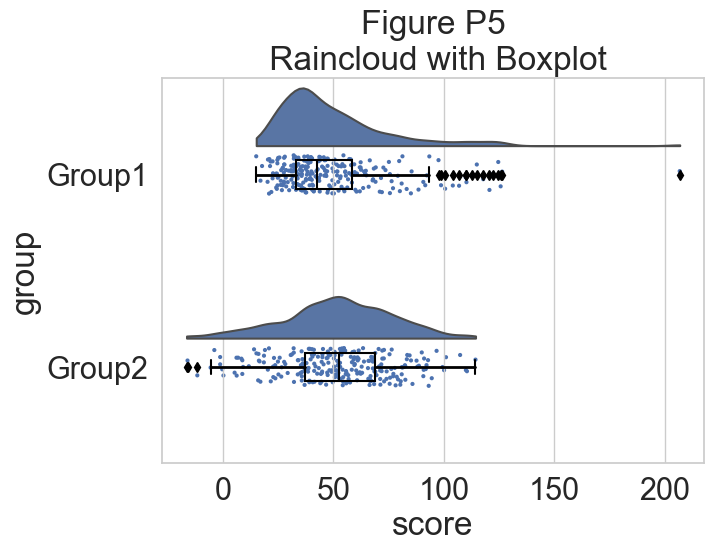

In [39]:
#adding the boxplot with quartiles
f, ax=plt.subplots(figsize=(7, 5))
ax=pt.half_violinplot(x=dx, y=dy, data=df, palette=pal, bw=.2, cut=0., 
                      scale="area", width=.6, inner=None, orient=ort)
ax=sns.stripplot(x=dx, y=dy, data=df, palette=pal, edgecolor="white",
                 size=3, jitter=1, zorder=0, orient=ort)
ax=sns.boxplot(x=dx, y=dy, data=df, color="black", width=.15, zorder=10, 
               showcaps=True, boxprops={'facecolor':'none',"zorder":10}, 
               showfliers=True, whiskerprops={'linewidth':2,"zorder":10},saturation=1, orient=ort)
plt.title("Figure P5\n Raincloud with Boxplot")
if savefigs:
    plt.savefig('figs/figureP05.png', bbox_inches='tight')


Text(0.5, 1.0, 'Figure P6\n Tweaking the Colour of Your Raincloud')

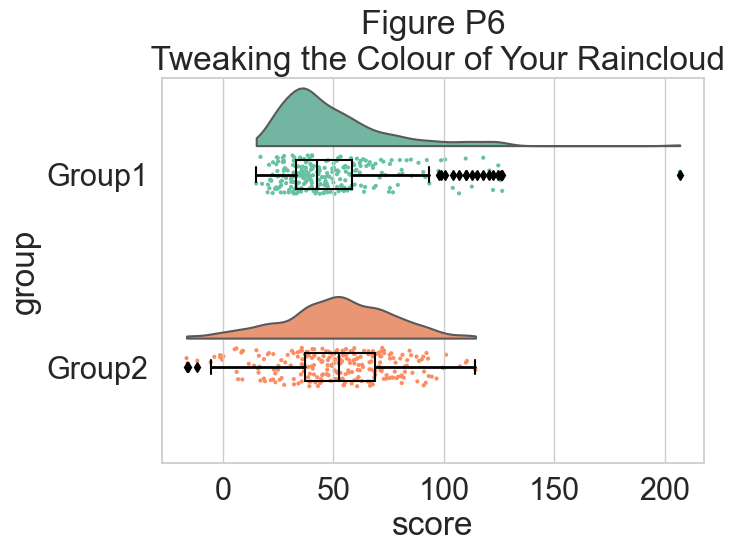

In [41]:
#adding color
pal="Set2"
f, ax=plt.subplots(figsize=(7, 5))
ax=pt.half_violinplot(x=dx, y=dy, data=df, palette=pal, bw=.2, cut=0.,
                      scale="area", width=.6, inner=None, orient=ort)
ax=sns.stripplot(x=dx, y=dy, data=df, palette=pal, edgecolor="white",
                 size=3, jitter=1, zorder=0, orient=ort)
ax=sns.boxplot(x=dx, y=dy, data=df, color="black", width=.15, zorder=10,
              showcaps=True, boxprops={'facecolor':'none',"zorder":10},
              showfliers=True, whiskerprops={'linewidth':2,"zorder":10},
              saturation=1, orient=ort)
plt.title("Figure P6\n Tweaking the Colour of Your Raincloud")


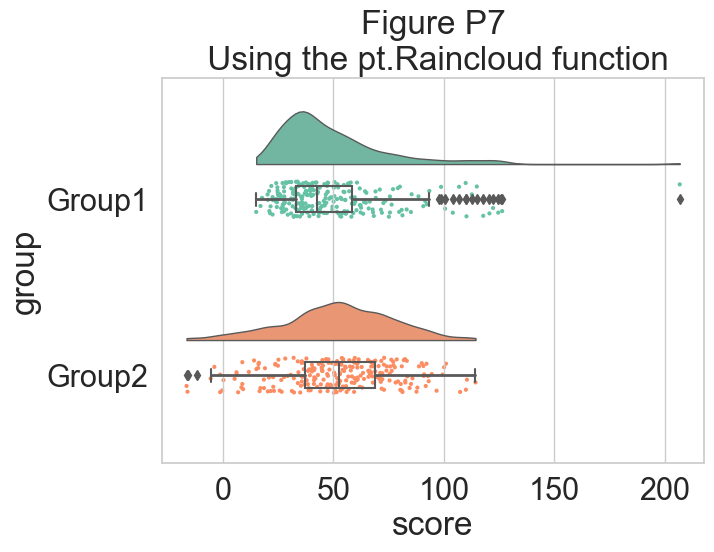

In [43]:
#same thing with a single command: now x **must** be the categorical value
dx="group"; dy="score"; ort="h"; pal="Set2"; sigma=.2
f, ax=plt.subplots(figsize=(7, 5))
pt.RainCloud(x=dx, y=dy, data=df, palette=pal, bw=sigma,
             width_viol = .6, ax = ax, orient = ort)
plt.title("Figure P7\n Using the pt.Raincloud function")
if savefigs:
    plt.savefig('figs/figureP07.png', bbox_inches='tight')


Text(0.5, 1.0, 'Figure P8\n Rainclouds with Shifted Rain')

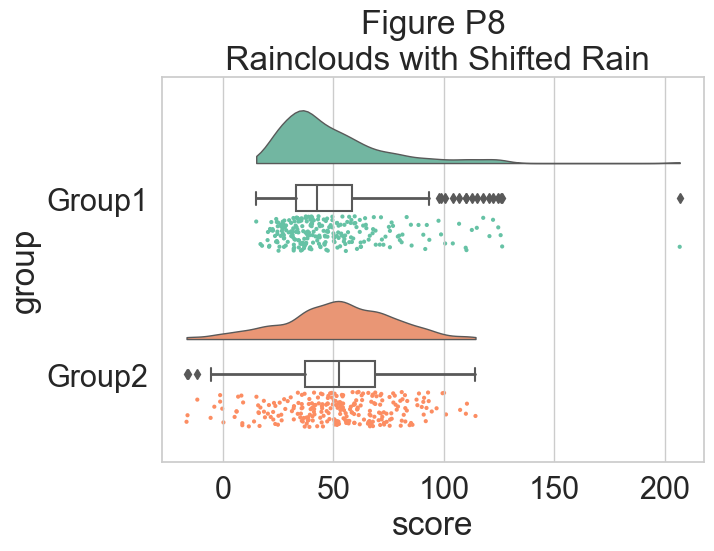

In [45]:
#moving the rain below the boxplot
dx="group"; dy="score"; ort="h"; pal="Set2"; sigma=.2
f,ax=plt.subplots(figsize=(7, 5))
ax=pt.RainCloud(x=dx, y=dy, data=df, palette=pal, bw=sigma,
                 width_viol=.6, ax=ax, orient=ort, move=.2)
plt.title("Figure P8\n Rainclouds with Shifted Rain")

In [ ]:
# Usage with a list/np.array input
dx=list(df["group"]); dy=list(df["score"])
f, ax=plt.subplots(figsize=(7, 5))
ax=pt.RainCloud(x=dx, y=dy, palette=pal, bw=sigma,
                 width_viol=.6, ax=ax, orient=ort)
plt.title("Figure P9\n Rainclouds with List/Array Inputs")

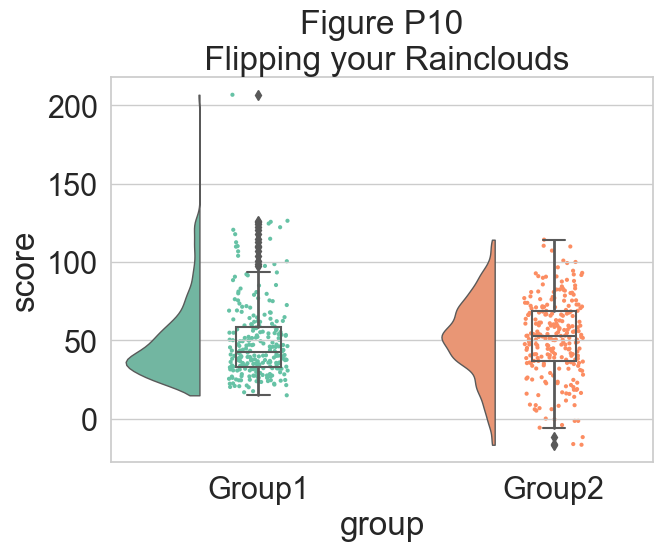

In [55]:
# Changing orientation
dx="group"; dy="score"; ort="v"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(7, 5))

ax=pt.RainCloud(x = dx, y = dy, data = df, palette = pal, bw = sigma,
                 width_viol = .5, ax = ax, orient = ort)

plt.title("Figure P10\n Flipping your Rainclouds")
if savefigs:
    plt.savefig('figs/figureP10.png', bbox_inches='tight')

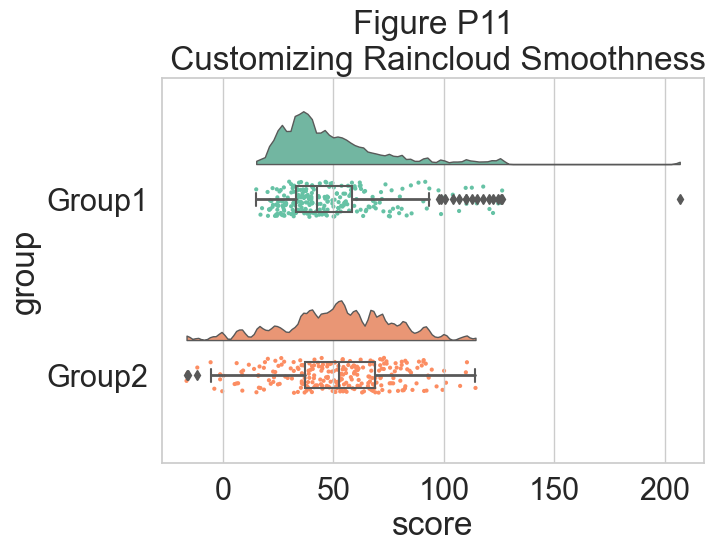

In [57]:
#changing cloud smoothness
dx="group"; dy="score"; ort="h"; pal = "Set2"; sigma = .05
f, ax = plt.subplots(figsize=(7, 5))

ax=pt.RainCloud(x = dx, y = dy, data = df, palette = pal, bw = sigma,
                 width_viol = .6, ax = ax, orient = ort)

plt.title("Figure P11\n Customizing Raincloud Smoothness")
if savefigs:
    plt.savefig('figs/figureP11.png', bbox_inches='tight')

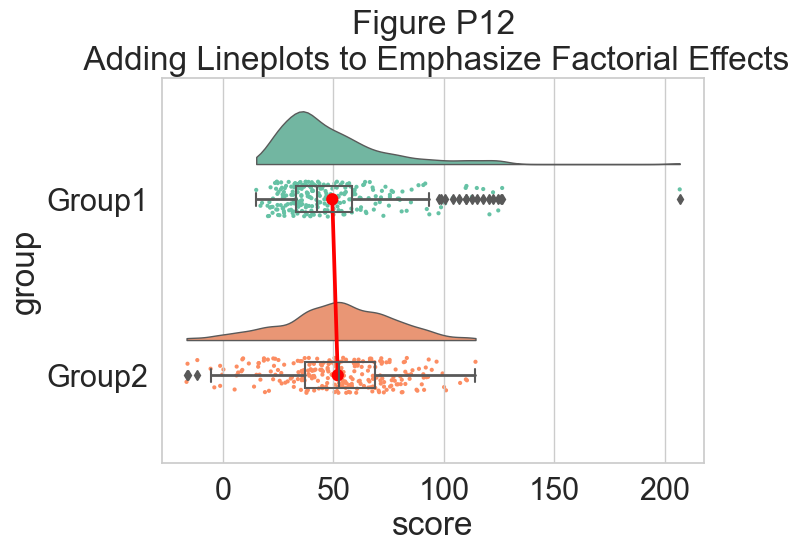

In [59]:
#adding a red line connecting the groups' mean value (useful for longitudinal data)
dx="group"; dy="score"; ort="h"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(7, 5))

ax=pt.RainCloud(x = dx, y = dy, data = df, palette = pal, bw = sigma,
                 width_viol = .6, ax = ax, orient = ort,
               pointplot = True)

plt.title("Figure P12\n Adding Lineplots to Emphasize Factorial Effects")
if savefigs:
    plt.savefig('figs/figureP12.png', bbox_inches='tight')

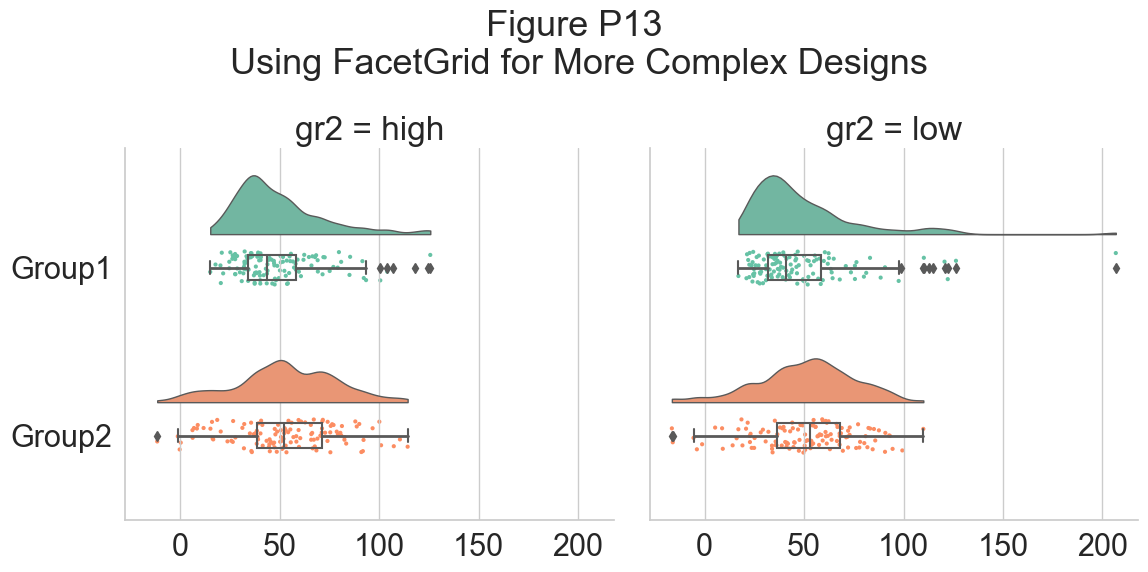

In [61]:
# Rainclouds with FacetGrid
g = sns.FacetGrid(df, col = "gr2", height = 6)
g = g.map_dataframe(pt.RainCloud, x = "group", y = "score", data = df,
                    orient = "h")

g.fig.subplots_adjust(top=0.75)
g.fig.suptitle("Figure P13\n Using FacetGrid for More Complex Designs",  fontsize=26)
if savefigs:
    plt.savefig('figs/figureP13.png', bbox_inches='tight')

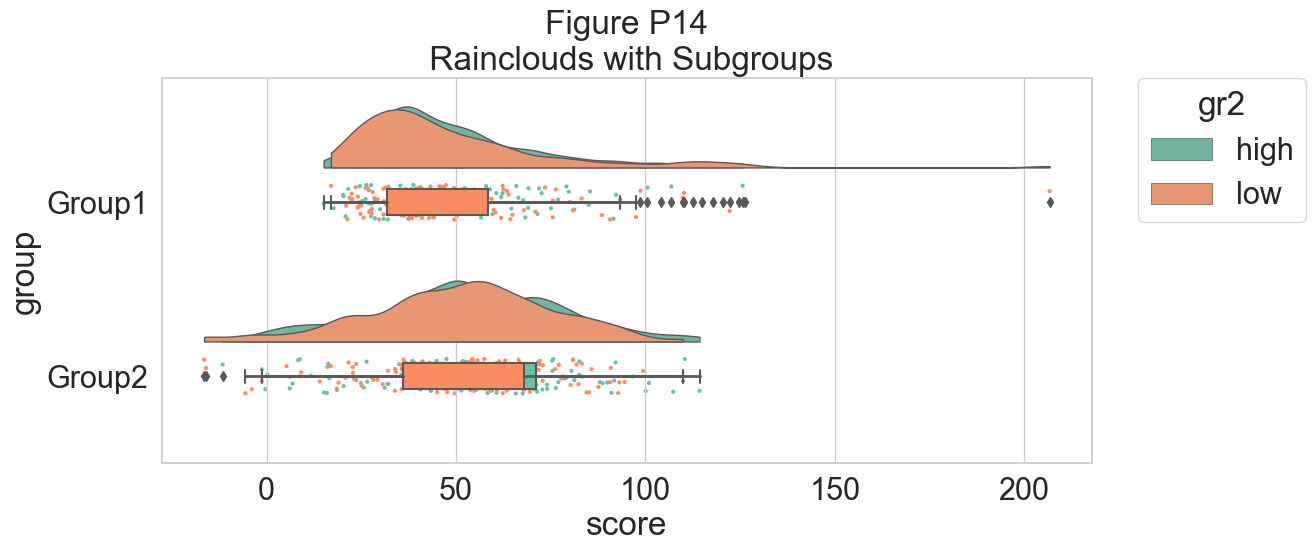

In [63]:
# Hue Input for Subgroups
dx="group"; dy="score"; dhue = "gr2"; ort="h"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(12, 5))

ax=pt.RainCloud(x = dx, y = dy, hue = dhue, data = df, palette = pal, bw = sigma,
                 width_viol = .7, ax = ax, orient = ort)

plt.title("Figure P14\n Rainclouds with Subgroups")
if savefigs:
    plt.savefig('figs/figureP14.png', bbox_inches='tight')

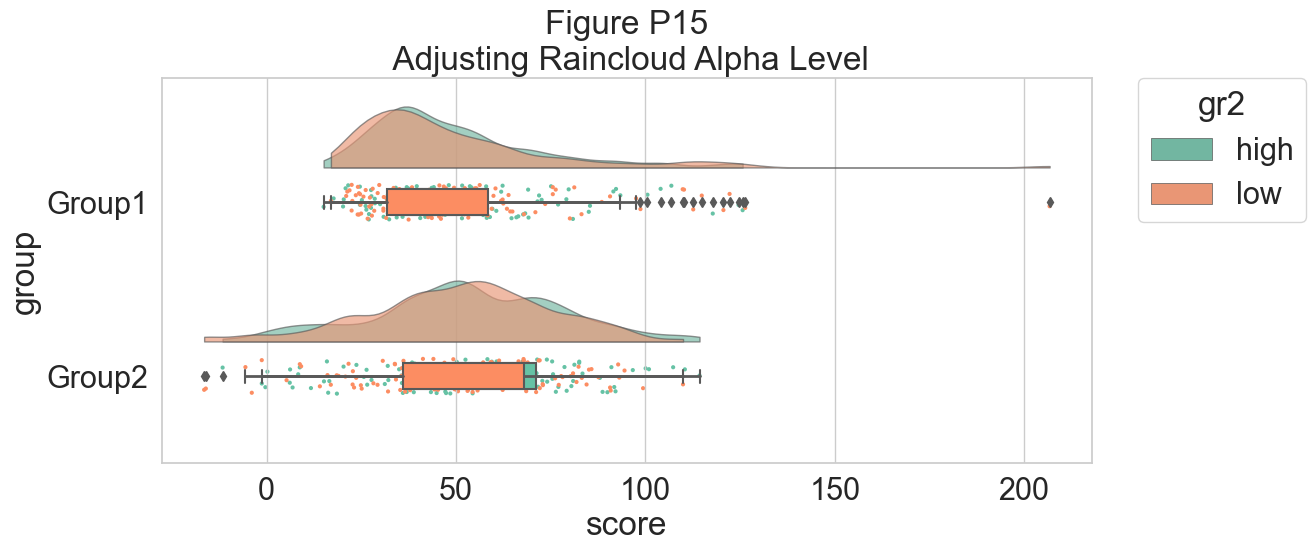

In [65]:
# Setting alpha level
f, ax = plt.subplots(figsize=(12, 5))

ax=pt.RainCloud(x = dx, y = dy, hue = dhue, data = df, palette = pal, bw = sigma,
                 width_viol = .7, ax = ax, orient = ort , alpha = .65)

plt.title("Figure P15\n Adjusting Raincloud Alpha Level")
if savefigs:
    plt.savefig('figs/figureP15.png', bbox_inches='tight')

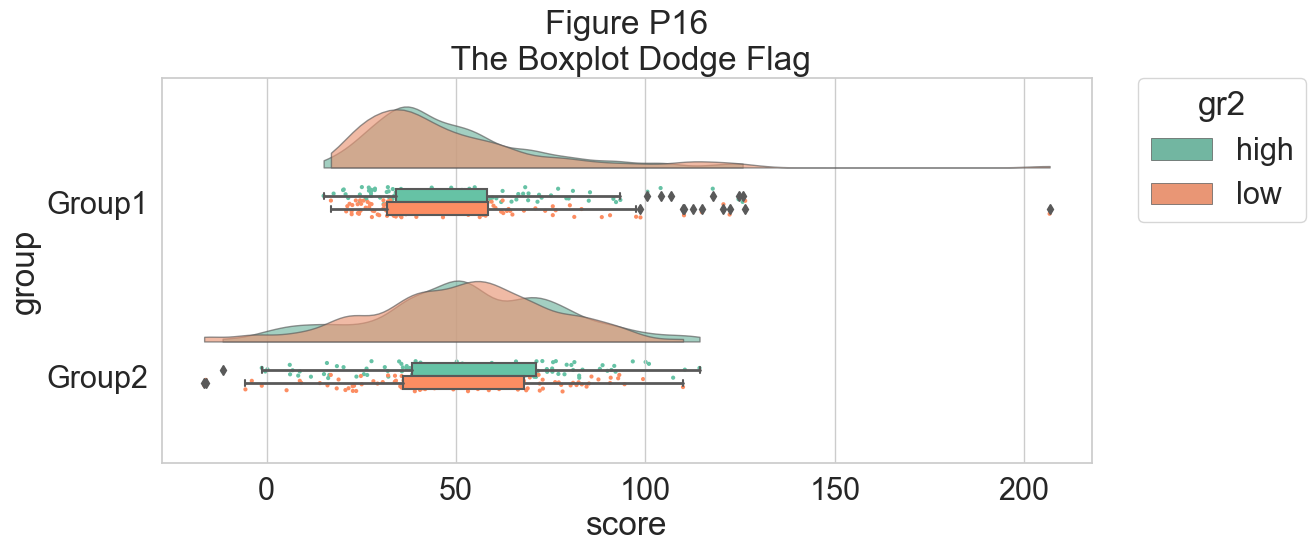

In [67]:
#The Doge Flag
f, ax = plt.subplots(figsize=(12, 5))

ax=pt.RainCloud(x = dx, y = dy, hue = dhue, data = df, palette = pal, bw = sigma,
                 width_viol = .7, ax = ax, orient = ort , alpha = .65, dodge = True)

plt.title("Figure P16\n The Boxplot Dodge Flag")
if savefigs:
    plt.savefig('figs/figureP16.png', bbox_inches='tight')

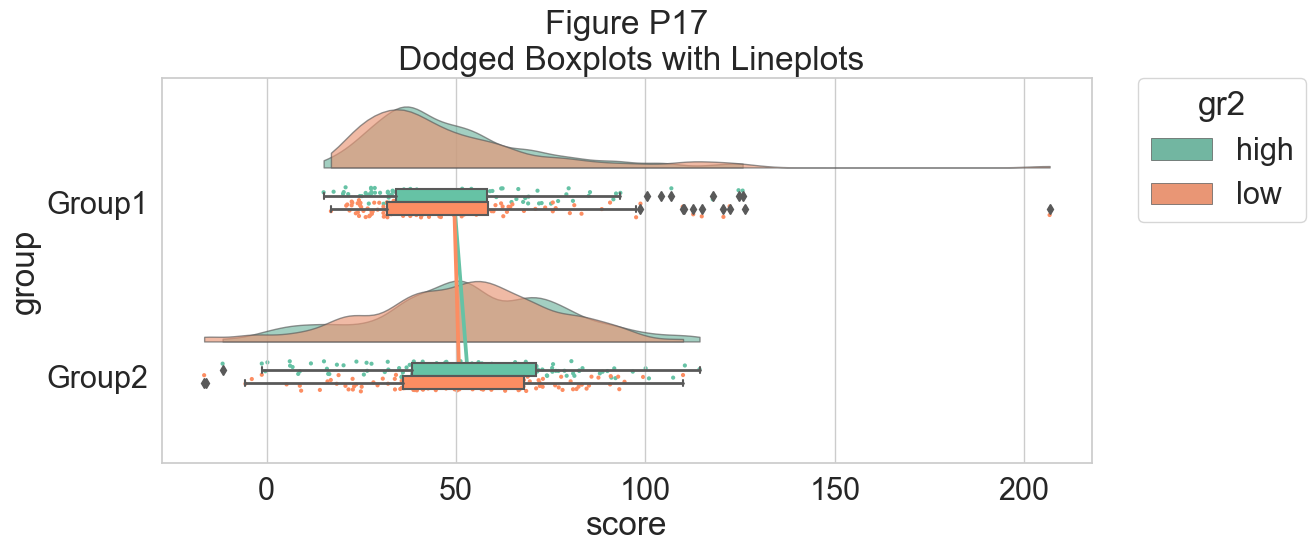

In [69]:
#same, with dodging and line
f, ax = plt.subplots(figsize=(12, 5))
ax=pt.RainCloud(x = dx, y = dy, hue = dhue, data = df, palette = pal, bw = sigma, width_viol = .7,
                ax = ax, orient = ort , alpha = .65, dodge = True, pointplot = True)

plt.title("Figure P17\n Dodged Boxplots with Lineplots")
if savefigs:
    plt.savefig('figs/figureP17.png', bbox_inches='tight')

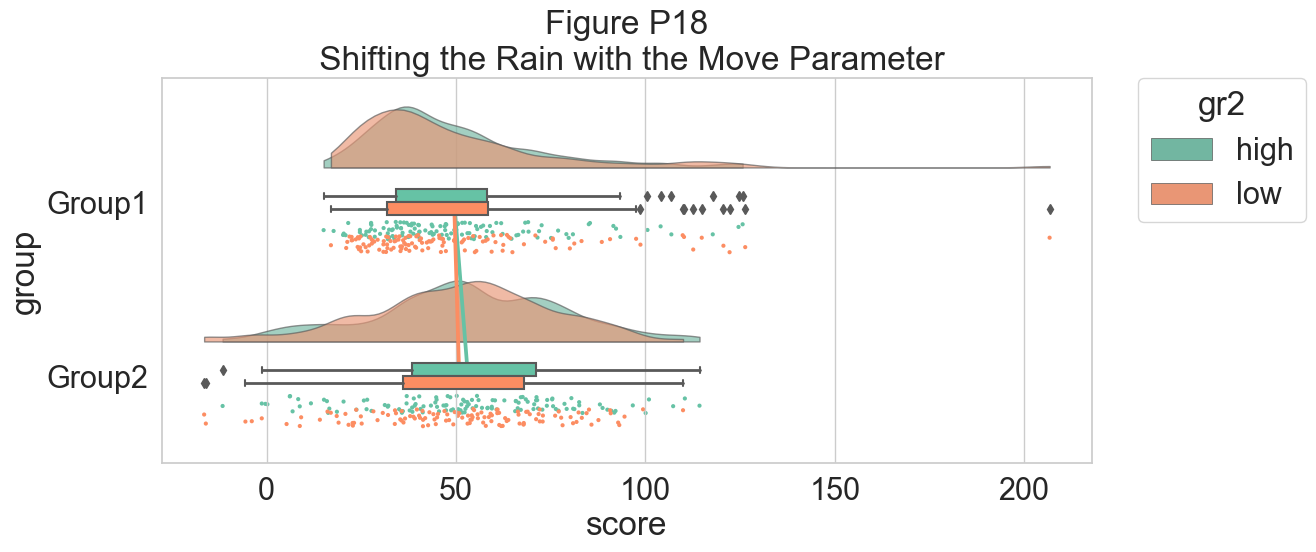

In [71]:
#moving the rain under the boxplot
f, ax = plt.subplots(figsize=(12, 5))

ax=pt.RainCloud(x = dx, y = dy, hue = dhue, data = df, palette = pal, bw = sigma, width_viol = .7,
                ax = ax, orient = ort , alpha = .65, dodge = True, pointplot = True, move = .2)

plt.title("Figure P18\n Shifting the Rain with the Move Parameter")
if savefigs:
    plt.savefig('figs/figureP18.png', bbox_inches='tight')

In [73]:
# Load in the repeated data
df_rep = pd.read_csv ("repeated_measures_data.csv", sep= ",")
df_rep.columns = ["score",  "timepoint", "group"]
df_rep.head()

,score,timepoint,group
0,5.57,1,1
1,7.43,1,1
2,4.37,1,1
3,8.22,1,1
4,8.17,1,1


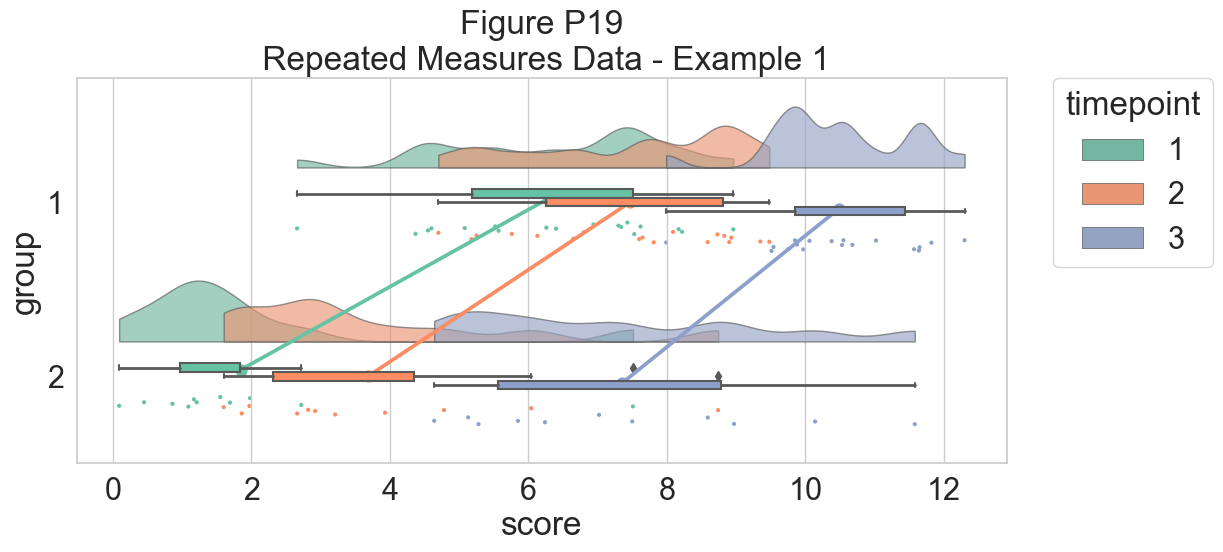

In [75]:
# Plot the repeated measures data
dx = "group"; dy = "score"; dhue = "timepoint"; ort = "h"; pal = "Set2"; sigma = .2
f, ax = plt.subplots(figsize=(12, 5))

ax=pt.RainCloud(x = dx, y = dy, hue = dhue, data = df_rep, palette = pal, bw = sigma, width_viol = .7,
                ax = ax, orient = ort , alpha = .65, dodge = True, pointplot = True, move = .2)

plt.title("Figure P19\n Repeated Measures Data - Example 1")
if savefigs:
    plt.savefig('figs/figureP19.png', bbox_inches='tight')

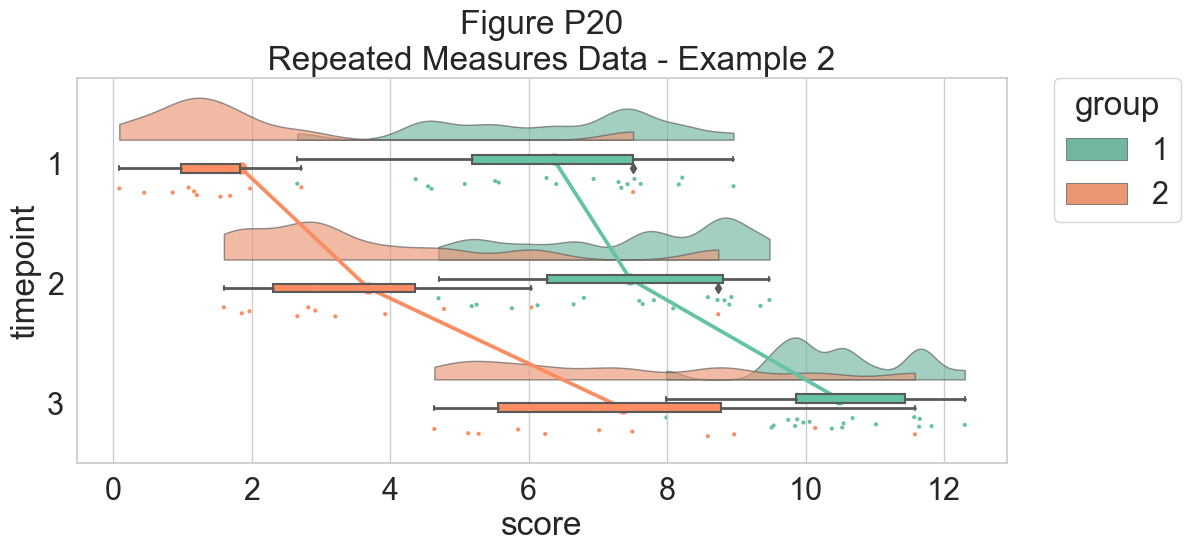

In [77]:
# Now with the group as hue
dx = "timepoint"; dy = "score"; dhue = "group"
f, ax = plt.subplots(figsize=(12, 5))

ax=pt.RainCloud(x = dx, y = dy, hue = dhue, data = df_rep, palette = pal, bw = sigma, width_viol = .7,
                ax = ax, orient = ort , alpha = .65, dodge = True, pointplot = True, move = .2)

plt.title("Figure P20\n  Repeated Measures Data - Example 2")
if savefigs:
    plt.savefig('figs/figureP20.png', bbox_inches='tight')